# EDA - AI Pension Advice Runs
Analysis of synthetic refugee profiles and consultant answer quality for the paper.

In [1]:
import json
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RUNS_PATH = Path('runs/runs.jsonl')
OUTPUT_DIR = Path('eda_figures')
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load & flatten data

In [35]:
records = []
with open(RUNS_PATH, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f'Total runs loaded: {len(records)}')

Total runs loaded: 500


In [60]:
def flatten(r: dict) -> dict:
    p = r['refugee']['profile_json']
    a = r['refugee']['anchors']
    persona = r['refugee'].get('persona_json', {})
    ev = r.get('evaluator', {})
    final = ev.get('final', {})
    rubric = ev.get('llm_rubric', {})
    scores = rubric.get('scores', {})
    det = ev.get('deterministic_checks', {})
    final_ans = r.get('consultant_final', {})
    draft = r.get('consultant_draft', {})

    expenses = (p['housing'] + p['utilities'] + p['food'] + p['transport']
                + p['healthcare'] + p['other'] + p['remittances'])
    surplus = p['income'] - expenses
    budget_ratio = expenses / p['income'] if p['income'] > 0 else None

    sources = final_ans.get('final_sources', [])
    source_types = Counter(s.get('source_type', 'unknown') for s in sources)

    issues = rubric.get('issues', [])
    issue_types = [i.get('type', 'unknown') for i in issues]

    return {
        'run_id': r['run_id'],
        'case_status': r['case_status'],
        'gender': a['gender'],
        'employment_status': a['employment_status'],
        'months': a['months'],
        'dependents': a['dependents'],
        'polish_language_level': a['polish_language_level'],
        'remittances_flag': a['remittances_flag'],
        'income': p['income'],
        'savings': p['savings'],
        'housing': p['housing'],
        'utilities': p['utilities'],
        'food': p['food'],
        'transport': p['transport'],
        'healthcare': p['healthcare'],
        'other': p['other'],
        'remittances': p['remittances'],
        'expenses_total': round(expenses, 2),
        'surplus': round(surplus, 2),
        'budget_ratio': round(budget_ratio, 3) if budget_ratio is not None else None,
        'age': persona.get('age'),
        'education': persona.get('education'),
        'city_tier': persona.get('city_tier'),
        'financial_literacy': persona.get('financial_literacy'),
        'risk_tolerance': persona.get('risk_tolerance'),
        'retirement_priority': persona.get('retirement_priority'),
        'has_dedicated_retirement_plan': persona.get('has_dedicated_retirement_plan'),
        'knows_if_enrolled_private_plan': persona.get('knows_if_enrolled_private_plan'),
        'overall_score': final.get('overall_score'),
        'allow_to_show': final.get('allow_to_show'),
        'grounded_only_pass': final.get('grounded_only_pass'),
        'score_groundedness': scores.get('groundedness'),
        'score_arithmetic': scores.get('arithmetic_consistency'),
        'score_actionability': scores.get('actionability'),
        'score_clarity': scores.get('clarity'),
        'score_safety': scores.get('safety_ethics'),
        'n_sources_total': len(sources),
        'n_citations': det.get('citation_count', 0),
        'n_src_vectorstore': source_types.get('vectorstore', 0),
        'n_src_live_web': source_types.get('live_web', 0),
        'n_src_tavily': source_types.get('tavily_search', 0),
        'n_issues': len(issues),
        'issue_types': issue_types,
        'has_missing_citation': 'missing_citation' in issue_types,
        'has_unsupported_claim': 'unsupported_claim' in issue_types,
        'has_math_error': 'math_error' in issue_types,
        'has_unsafe_overconfidence': 'unsafe_overconfidence' in issue_types,
        'has_private_program_hallucination': 'private_program_hallucination' in issue_types,
        'repair_issues': final_ans.get('repair_issues', []),
        'n_clarifying_questions': len(draft.get('clarifying_questions', [])),
    }

df = pd.DataFrame([flatten(r) for r in records])

emp_order = ['permanent_job', 'self_employed', 'other_work', 'unemployed', 'economically_inactive']
lang_order = ['none', 'basic', 'intermediate', 'advanced']
df['employment_status'] = pd.Categorical(df['employment_status'], categories=emp_order, ordered=True)
df['polish_language_level'] = pd.Categorical(df['polish_language_level'], categories=lang_order, ordered=True)

emp_labels = {
    'permanent_job': 'Permanent job', 'self_employed': 'Self-employed',
    'other_work': 'Other work', 'unemployed': 'Unemployed',
    'economically_inactive': 'Inactive'
}
score_cols = ['score_groundedness', 'score_arithmetic', 'score_actionability',
              'score_clarity', 'score_safety', 'overall_score']
score_labels_list = ['Groundedness', 'Arithmetic', 'Actionability', 'Clarity', 'Safety', 'Overall']
n_total = len(df)

print(f'Total cases: {n_total}')
df.head(3)

Total cases: 500


,run_id,case_status,gender,employment_status,months,dependents,polish_language_level,remittances_flag,income,savings,...,n_src_tavily,n_issues,issue_types,has_missing_citation,has_unsupported_claim,has_math_error,has_unsafe_overconfidence,has_private_program_hallucination,repair_issues,n_clarifying_questions
0,bb439067-fbc4-4a6c-ac8f-240f267fb605,accepted,female,permanent_job,14,2,advanced,1,2390.0,310.0,...,0,1,[unsupported_claim],False,True,False,False,False,[],3
1,670e8e2c-d606-4376-82c8-0e0101a2a848,accepted,male,permanent_job,17,0,basic,1,6920.0,590.0,...,0,1,[unsupported_claim],False,True,False,False,False,[],3
2,eddef0c1-938c-4cd4-ac80-3a7f76188bd6,accepted,male,self_employed,38,1,intermediate,0,3410.0,600.0,...,0,1,[unsupported_claim],False,True,False,False,False,[],3


## 3.1. Overview of the generated synthetic dataset

In [61]:
# Table 4. Overview of the generated advisory dataset
table4 = pd.DataFrame({
    'Metric': [
        'Total generated cases',
        'Accepted cases',
        'Needs-review cases',
        'Flagged cases',
        'Cases with final recommendation',
        'Cases with evaluator output',
    ],
    'Value': [
        n_total,
        int((df.case_status == 'accepted').sum()),
        int((df.case_status == 'needs_review').sum()),
        int((df.case_status == 'flagged').sum()),
        int(df['overall_score'].notna().sum()),
        int(df['overall_score'].notna().sum()),
    ]
})
print('Table 4. Overview of the generated advisory dataset\n')
display(table4.style.hide(axis='index'))

Table 4. Overview of the generated advisory dataset



Metric,Value
Total generated cases,500
Accepted cases,327
Needs-review cases,170
Flagged cases,3
Cases with final recommendation,500
Cases with evaluator output,500


## 3.2. Profile-level and budget-level exploratory analysis

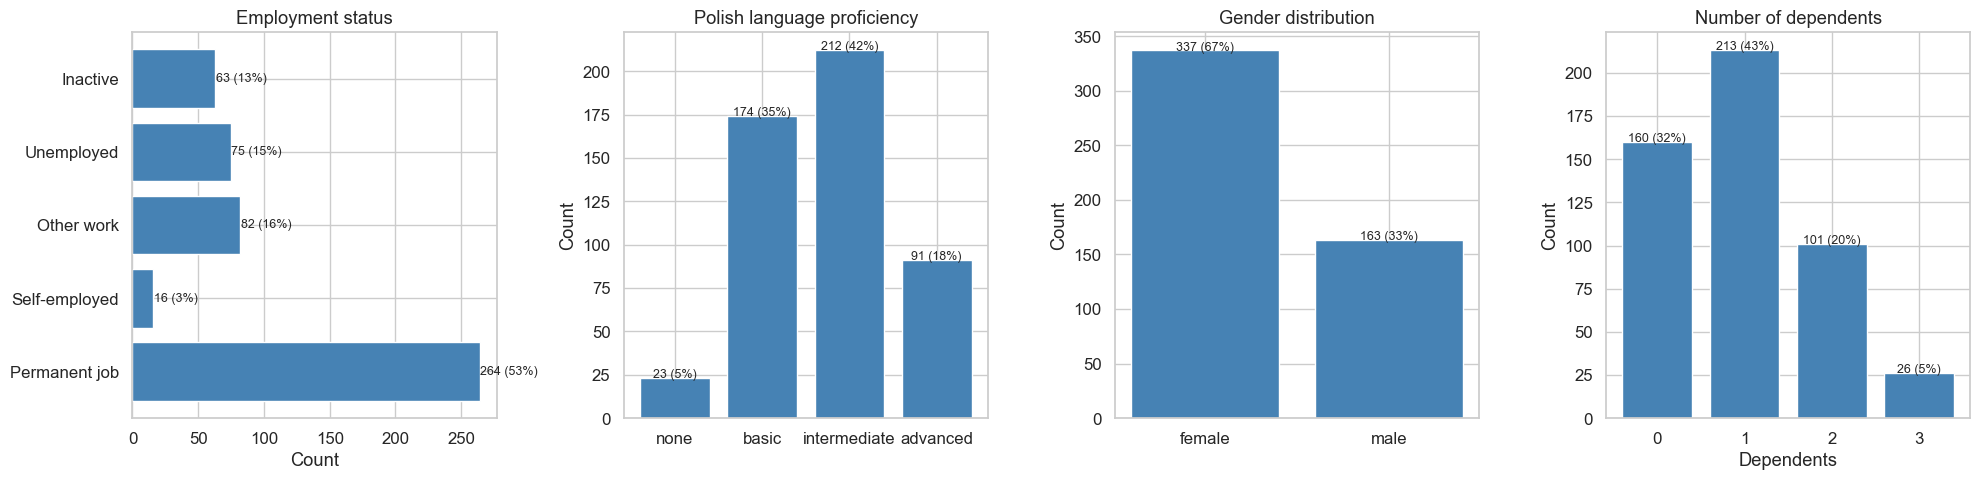

In [62]:
# Fig. 2. Distribution of employment status, Polish language proficiency, gender, and dependents
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

emp_present = [e for e in emp_order if e in df['employment_status'].values]
emp_counts = df['employment_status'].value_counts().reindex(emp_present)
bars = axes[0].barh(
    [emp_labels.get(e, e) for e in emp_present],
    emp_counts.values,
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Employment status')
axes[0].set_xlabel('Count')
for bar, v in zip(bars, emp_counts.values):
    axes[0].text(v + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'{v} ({v / n_total * 100:.0f}%)', va='center', fontsize=9)

lang_present = [l for l in lang_order if l in df['polish_language_level'].values]
lang_counts = df['polish_language_level'].value_counts().reindex(lang_present)
axes[1].bar(lang_present, lang_counts.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('Polish language proficiency')
axes[1].set_ylabel('Count')
for i, v in enumerate(lang_counts.values):
    axes[1].text(i, v + 0.2, f'{v} ({v / n_total * 100:.0f}%)', ha='center', fontsize=9)

gender_counts = df['gender'].value_counts()
axes[2].bar(gender_counts.index, gender_counts.values,
            color='steelblue', edgecolor='white')
axes[2].set_title('Gender distribution')
axes[2].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[2].text(i, v + 0.2, f'{v} ({v / n_total * 100:.0f}%)', ha='center', fontsize=9)

dep_counts = df['dependents'].value_counts().sort_index()
axes[3].bar(dep_counts.index.astype(str), dep_counts.values,
            color='steelblue', edgecolor='white')
axes[3].set_title('Number of dependents')
axes[3].set_xlabel('Dependents')
axes[3].set_ylabel('Count')
for i, v in enumerate(dep_counts.values):
    axes[3].text(i, v + 0.2, f'{v} ({v / n_total * 100:.0f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_employment_language_gender.png', dpi=150, bbox_inches='tight')
plt.show()


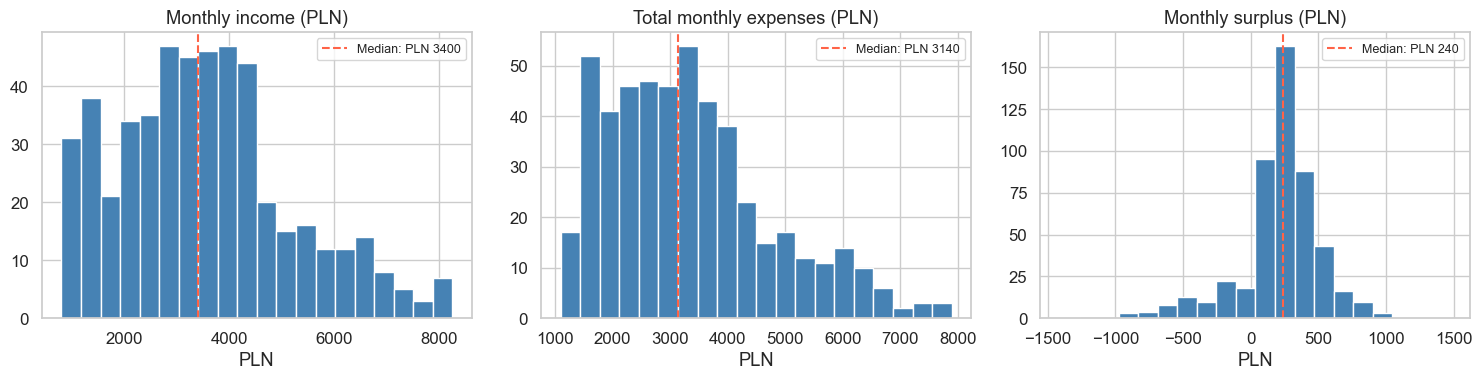

       income  expenses_total  surplus
count   500.0           500.0    500.0
mean   3529.0          3311.0    217.0
std    1661.0          1436.0    319.0
min     800.0          1100.0  -1410.0
25%    2315.0          2220.0    110.0
50%    3400.0          3140.0    240.0
75%    4382.0          4020.0    360.0
max    8250.0          7890.0   1480.0


In [63]:
# Fig. 3. Monthly income, total expenses, and surplus distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['income'], bins=20, edgecolor='white', color='steelblue')
axes[0].axvline(df['income'].median(), color='tomato', linestyle='--',
                label=f'Median: PLN {df["income"].median():.0f}')
axes[0].set_title('Monthly income (PLN)')
axes[0].set_xlabel('PLN')
axes[0].legend(fontsize=9)

axes[1].hist(df['expenses_total'], bins=20, edgecolor='white', color='steelblue')
axes[1].axvline(df['expenses_total'].median(), color='tomato', linestyle='--',
                label=f'Median: PLN {df["expenses_total"].median():.0f}')
axes[1].set_title('Total monthly expenses (PLN)')
axes[1].set_xlabel('PLN')
axes[1].legend(fontsize=9)

axes[2].hist(df['surplus'], bins=20, edgecolor='white', color='steelblue')
axes[2].axvline(df['surplus'].median(), color='tomato', linestyle='--',
                label=f'Median: PLN {df["surplus"].median():.0f}')
axes[2].set_title('Monthly surplus (PLN)')
axes[2].set_xlabel('PLN')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_income_expenses_surplus.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['income', 'expenses_total', 'surplus']].describe().round(0).to_string())

C:\Users\lyasy\AppData\Local\Temp\ipykernel_22792\1632830590.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='employment_status', y='surplus',
C:\Users\lyasy\AppData\Local\Temp\ipykernel_22792\1632830590.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([emp_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
C:\Users\lyasy\AppData\Local\Temp\ipykernel_22792\1632830590.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


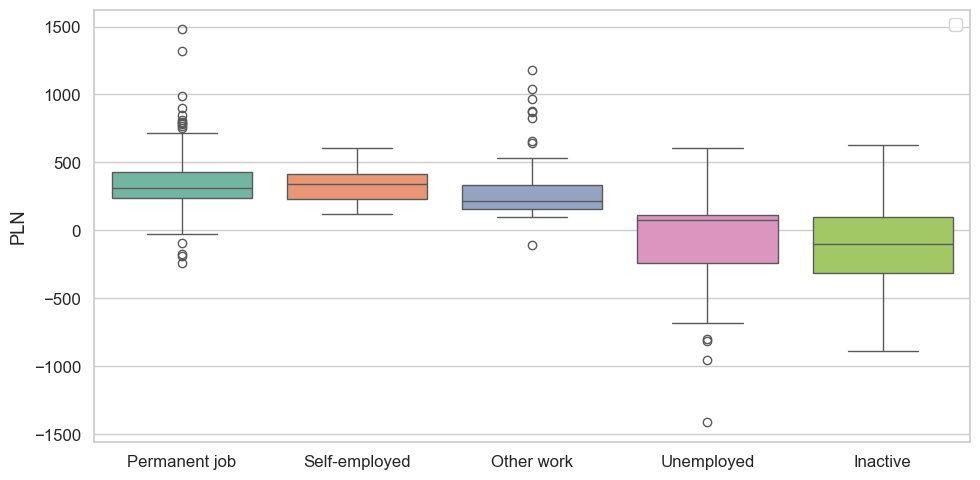


Median monthly surplus by employment status:
                       median   mean    std
employment_status                          
permanent_job           315.0  356.0  196.0
self_employed           340.0  336.0  140.0
other_work              220.0  297.0  228.0
unemployed               80.0  -79.0  348.0
economically_inactive  -100.0 -147.0  324.0


In [64]:
# Fig. 4. Monthly surplus by employment status
emp_present = [e for e in emp_order if e in df['employment_status'].values]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='employment_status', y='surplus',
            order=emp_present, palette='Set2', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('PLN')
ax.set_xticklabels([emp_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_surplus_by_employment.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMedian monthly surplus by employment status:')
print(df.groupby('employment_status', observed=True)['surplus']
      .agg(['median', 'mean', 'std']).round(0).to_string())

## 3.3. Evaluation outcomes and deterministic safeguards

In [65]:
# Table 5. Evaluation outcomes by case status
status_counts = df['case_status'].value_counts().reset_index()
status_counts.columns = ['Case status', 'Number']
status_counts['Percentage'] = (status_counts['Number'] / n_total * 100).round(1).astype(str) + '%'
status_counts['Case status'] = status_counts['Case status'].str.replace('_', ' ').str.title()
status_counts = status_counts.sort_values('Number', ascending=False).reset_index(drop=True)

print('Table 5. Evaluation outcomes by case status\n')
display(status_counts.style.hide(axis='index'))

Table 5. Evaluation outcomes by case status



Case status,Number,Percentage
Accepted,327,65.4%
Needs Review,170,34.0%
Flagged,3,0.6%


In [66]:
# Table 6. Descriptive statistics of evaluator scores
score_df = df[score_cols].copy()
score_df.columns = score_labels_list

stats = score_df.agg(['mean', 'std', 'median', 'min', 'max']).T.round(2)
stats.columns = ['Mean', 'SD', 'Median', 'Min', 'Max']
stats.index.name = 'Dimension'

print('Table 6. Descriptive statistics of evaluator scores\n')
display(stats)

Table 6. Descriptive statistics of evaluator scores



,Mean,SD,Median,Min,Max
Dimension,,,,,
Groundedness,8.04,0.34,8.0,6.0,10.0
Arithmetic,9.99,0.18,10.0,6.0,10.0
Actionability,8.79,0.43,9.0,7.0,10.0
Clarity,9.03,0.18,9.0,9.0,10.0
Safety,8.73,0.52,9.0,7.0,10.0
Overall,8.64,0.61,9.0,6.0,10.0


In [67]:
# Table 7. Frequency of deterministic flags
# Table 7. Frequency of deterministic flags
flags = {
    'Missing citation': df['has_missing_citation'].sum(),
    'Unknown / unsupported citation': df['has_unsupported_claim'].sum(),
    'Unsafe or overconfident claim': df['has_unsafe_overconfidence'].sum(),
    'Arithmetic mismatch': df['has_math_error'].sum(),
    'Unsupported private-program mention': df['has_private_program_hallucination'].sum(),
}


table7 = pd.DataFrame({
    'Check': list(flags.keys()),
    'Number of cases': list(flags.values()),
    'Percentage': [f'{v / n_total * 100:.1f}%' for v in flags.values()],
})

print('Table 7. Frequency of deterministic flags\n')
display(table7.style.hide(axis='index'))

Table 7. Frequency of deterministic flags



Check,Number of cases,Percentage
Missing citation,150,30.0%
Unknown / unsupported citation,322,64.4%
Unsafe or overconfident claim,100,20.0%
Arithmetic mismatch,1,0.2%
Unsupported private-program mention,0,0.0%


## 3.4. Relationship between profile characteristics and recommendation quality

C:\Users\lyasy\AppData\Local\Temp\ipykernel_22792\2356709765.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='employment_status', y='overall_score',
C:\Users\lyasy\AppData\Local\Temp\ipykernel_22792\2356709765.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(emp_labels_short, rotation=15, ha='right')
C:\Users\lyasy\AppData\Local\Temp\ipykernel_22792\2356709765.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='employment_status', y='score_actionability',
C:\Users\lyasy\AppData\Local\Temp\ipykernel_22792\2356709765.py:17: UserWarning: set_ticklabels() 

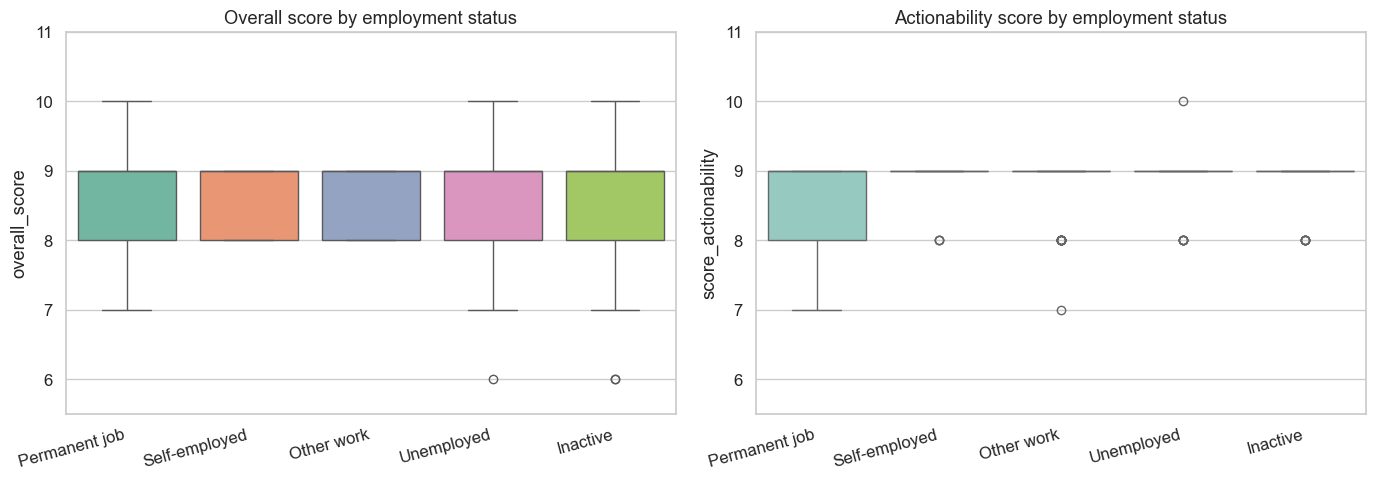


Mean overall score by employment status:
                       mean  median  count
employment_status                         
permanent_job          8.65     9.0    264
self_employed          8.56     9.0     16
other_work             8.71     9.0     82
unemployed             8.60     9.0     75
economically_inactive  8.56     9.0     63


In [58]:
# Overall score and actionability score by employment status
emp_present = [e for e in emp_order if e in df['employment_status'].values]
emp_labels_short = [emp_labels.get(e, e) for e in emp_present]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='employment_status', y='overall_score',
            order=emp_present, palette='Set2', ax=axes[0])
axes[0].set_title('Overall score by employment status')
axes[0].set_xticklabels(emp_labels_short, rotation=15, ha='right')
axes[0].set_ylim(5.5, 11)
axes[0].set_xlabel('')

sns.boxplot(data=df, x='employment_status', y='score_actionability',
            order=emp_present, palette='Set3', ax=axes[1])
axes[1].set_title('Actionability score by employment status')
axes[1].set_xticklabels(emp_labels_short, rotation=15, ha='right')
axes[1].set_ylim(5.5, 11)
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_score_by_employment.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean overall score by employment status:')
print(df.groupby('employment_status', observed=True)['overall_score']
      .agg(['mean', 'median', 'count']).round(2).to_string())


In [53]:
# Low-surplus profiles and profiles with dependents
df['low_surplus'] = df['surplus'] <= 0
df['has_dependents'] = df['dependents'] > 0
unemployed_mask = df['employment_status'].isin(['unemployed', 'economically_inactive'])

print('=== Low-surplus (deficit) profiles ===')
print(f'Cases with deficit (surplus <= 0): {df["low_surplus"].sum()} ({df["low_surplus"].mean()*100:.1f}%)')
if df['low_surplus'].sum() > 0:
    print('Case status breakdown for deficit profiles:')
    print(df[df['low_surplus']]['case_status'].value_counts().to_string())
    print(f'Mean score — deficit:  {df[df["low_surplus"]]["overall_score"].mean():.2f}')
    print(f'Mean score — surplus:  {df[~df["low_surplus"]]["overall_score"].mean():.2f}')

print('\n=== Profiles with dependents ===')
print(f'Cases with dependents: {df["has_dependents"].sum()} ({df["has_dependents"].mean()*100:.1f}%)')
print(f'Mean actionability — with dependents:    {df[df["has_dependents"]]["score_actionability"].mean():.2f}')
print(f'Mean actionability — without dependents: {df[~df["has_dependents"]]["score_actionability"].mean():.2f}')

print('\n=== Actionability: unemployed/inactive vs employed ===')
print(f'Unemployed/inactive — mean actionability: {df[unemployed_mask]["score_actionability"].mean():.2f}')
print(f'Employed            — mean actionability: {df[~unemployed_mask]["score_actionability"].mean():.2f}')

=== Low-surplus (deficit) profiles ===
Cases with deficit (surplus <= 0): 75 (15.0%)
Case status breakdown for deficit profiles:
case_status
accepted        47
needs_review    25
flagged          3
Mean score — deficit:  8.60
Mean score — surplus:  8.64

=== Profiles with dependents ===
Cases with dependents: 340 (68.0%)
Mean actionability — with dependents:    8.96
Mean actionability — without dependents: 8.42

=== Actionability: unemployed/inactive vs employed ===
Unemployed/inactive — mean actionability: 8.91
Employed            — mean actionability: 8.74


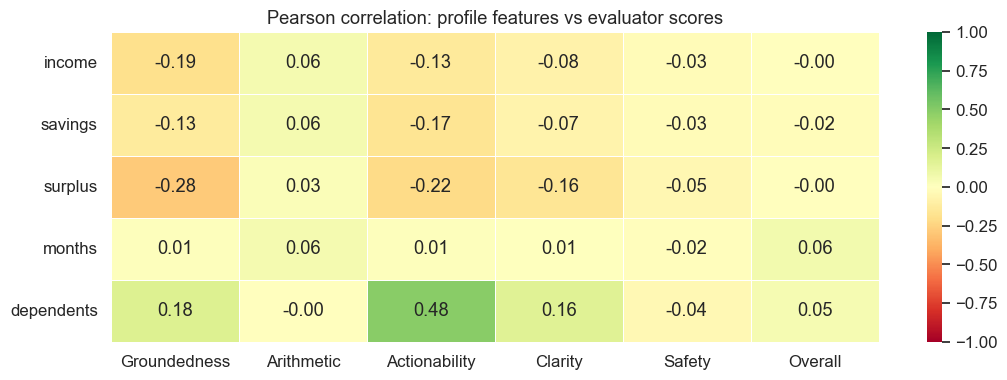

In [54]:
# Pearson correlation: profile features vs evaluator scores
numeric_profile = ['income', 'savings', 'surplus', 'months', 'dependents']
corr_df = df[numeric_profile + score_cols].copy()
corr_df.columns = numeric_profile + score_labels_list
corr = corr_df.corr(numeric_only=True).loc[numeric_profile, score_labels_list]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pearson correlation: profile features vs evaluator scores')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# Example cases: 1 accepted (highest score) + 1 needs_review/flagged
accepted_cases = df[df['case_status'] == 'accepted']
non_accepted = df[df['case_status'].isin(['needs_review', 'flagged'])]

print('=== Example: ACCEPTED case (highest overall score) ===')
if not accepted_cases.empty:
    row = accepted_cases.nlargest(1, 'overall_score').iloc[0]
    rec = next(r for r in records if r['run_id'] == row['run_id'])
    print(f'employment: {row["employment_status"]}  |  income: PLN {row["income"]:.0f}  |  surplus: PLN {row["surplus"]:.0f}')
    print(f'overall_score: {row["overall_score"]}  |  groundedness: {row["score_groundedness"]}  |  actionability: {row["score_actionability"]}')
    print(f'\nProfile:\n{rec["refugee"]["profile_text"][:400]}')
    print(f'\nFinal answer (excerpt):\n{rec["consultant_final"]["final_answer"][:600]}')

print('\n' + '=' * 70)
print('=== Example: NEEDS-REVIEW / FLAGGED case ===')
if not non_accepted.empty:
    row2 = non_accepted.nsmallest(1, 'overall_score').iloc[0]
    rec2 = next(r for r in records if r['run_id'] == row2['run_id'])
    print(f'status: {row2["case_status"]}')
    print(f'employment: {row2["employment_status"]}  |  income: PLN {row2["income"]:.0f}  |  surplus: PLN {row2["surplus"]:.0f}')
    print(f'overall_score: {row2["overall_score"]}  |  issues: {row2["issue_types"]}')
    print(f'\nProfile:\n{rec2["refugee"]["profile_text"][:400]}')
    print(f'\nFinal answer (excerpt):\n{rec2["consultant_final"]["final_answer"][:600]}')
else:
    print('No needs_review or flagged cases — all cases accepted.')
    print('\nExample: ACCEPTED case with LOWEST score:')
    row2 = accepted_cases.nsmallest(1, 'overall_score').iloc[0]
    rec2 = next(r for r in records if r['run_id'] == row2['run_id'])
    print(f'overall_score: {row2["overall_score"]}  |  issues: {row2["issue_types"]}')
    print(f'\nProfile:\n{rec2["refugee"]["profile_text"][:400]}')
    print(f'\nFinal answer (excerpt):\n{rec2["consultant_final"]["final_answer"][:600]}')

=== Example: ACCEPTED case (highest overall score) ===
employment: unemployed  |  income: PLN 1780  |  surplus: PLN 90
overall_score: 10  |  groundedness: 10  |  actionability: 9

Profile:
Monthly income: PLN 1780
Current savings: PLN 20
Monthly expenses:
- Housing: PLN 700
- Utilities: PLN 90
- Food: PLN 600
- Transportation: PLN 60
- Healthcare: PLN 40
- Other: PLN 200
- Remittances: PLN 0
Has 1 dependent(s)
Employment status: unemployed
Gender: male
Lives in Poland for 8 month(s)
Polish language level: intermediate

Final answer (excerpt):
1) Summary: You currently have a small monthly surplus of PLN 90, which limits how much you can save for retirement without tightening your budget too much. Since you are unemployed and not making ZUS pension contributions, your future state pension may be reduced. You may consider voluntary ZUS contributions, but they can be costly on a low income. Additionally, as a parent of one dependent child, you may be eligible for the Rodzina 800+ benefit,